### **Imports** 

In [6]:
import numpy as np
import sys, os
from autograd import grad, hessian
import autograd.numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
import pandas as pd
from utils import *
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import matplotlib.colors as mcolors
from sklearn.multioutput import MultiOutputRegressor



### **Using Support Vector Machines for Nonlinear Classification** <br>


**Predicting the mass loss of a stellar collision** <br> 


In [7]:
# Load the data 
data = np.load('../../data_splits_splot22f_1008.npz')
X_train = data['X_train']
y_train = data['y_train'][:, 1:]
X_val = data['X_val']
y_val = data['y_val'][:, 1:]
X_test = data['X_test']
y_test = data['y_test'][:, 1:]

#Standard normalize the training data and use the mean and std to normalize the testing data
svr_scaler = StandardScaler().fit(X_train)
X_train = svr_scaler.transform(X_train)
X_test = svr_scaler.transform(X_test)
X_val = svr_scaler.transform(X_val)

print("Training set ", np.shape(X_train), np.shape(y_train))
print("Validation set ", np.shape(X_val), np.shape(y_val))
print("Testing set ", np.shape(X_test), np.shape(y_test))


Training set  (17739, 5) (17739, 3)
Validation set  (3801, 5) (3801, 3)
Testing set  (3802, 5) (3802, 3)


In [8]:

# Create a split indicator array
# -1 means "use for training", 0 means "use for validation"
split_index = np.concatenate([
    np.full(len(X_train), -1),  # All train samples get -1
    np.zeros(len(X_val))         # All val samples get 0
])

# Combine train and validation sets
X_train_val = np.vstack([X_train, X_val])
y_train_val = np.concatenate([y_train, y_val], axis=0)

# Create the predefined split
ps = PredefinedSplit(test_fold=split_index)

# Performing one-versus-rest 
parameters = {'estimator__kernel':['rbf','sigmoid'], 'estimator__C':[ 0.1, 1, 10, 100], 'estimator__gamma':[0.01, 0.1, 1], 'estimator__coef0':[0.01, 0.1, 1]}
svr = MultiOutputRegressor(SVR())
svr_grid = GridSearchCV(estimator = svr, param_grid = parameters, scoring = 'neg_mean_squared_error', cv = ps, n_jobs=-1)
svr_grid.fit(X_train_val, y_train_val)

# Save the best-performing model 
joblib.dump(svr.best_estimator_, 'regression/models/svr_best_model.pkl')
joblib.dump(svr, 'regression/models/svr_scaler.pkl')

# Also save best parameters for reference
results = {
    'best_params': svr.best_params_,
    'best_score': svr.best_score_,
    'cv_results': svr.cv_results_
}

joblib.dump(results, 'regression/models/svr_training_info.pkl')

model = svr.best_estimator_

In [29]:
#--- Checking the results from the gridsearch ---#
#09/24 
# SVR(C=100, coef0=0.01, gamma=1)


# Commented out for the pdf
# results_svr = pd.DataFrame(model.cv_results_)
best_model_svr = svr_grid.best_estimator_
# print(results_svr[['params', 'mean_test_score', 'std_test_score']])
# print(svr.best_params_)



In [31]:
#---Checking the accuracy of the model on the testing data set---#
y_pred = best_model_svr.predict(X_test)

# Calculate absolute and relative errors for each mass component 
X_test_unnormalized = svr_scaler.inverse_transform(X_test)
mass1i = np.exp(X_test_unnormalized[:, 3] )
mass2i = np.exp(X_test_unnormalized[:, 4] )

initial_total_masses = mass1i + mass2i # in Msun 
pred_mass1 = y_pred[:,0] * initial_total_masses
pred_mass2 = y_pred[:,1] * initial_total_masses
pred_ejec  = y_pred[:,2] * initial_total_masses

true_mass1 = y_test[:,0] * initial_total_masses
true_mass2 = y_test[:,1] * initial_total_masses
true_ejec  = y_test[:,2] * initial_total_masses


#--Error metric 1: Median Absolute Errors for the respective masses 
median_abs_error_m1 = np.median(np.abs(pred_mass1 - true_mass1))
median_abs_error_m2 = np.median(np.abs(pred_mass2 - true_mass2))
median_abs_error_ejec = np.median(np.abs(pred_ejec - true_ejec))


#--Error metric 2: Relative errors for cases where at least one star survives

median_rel_error_m1 = np.median(np.abs(pred_mass1[true_mass1 != 0.] - true_mass1[true_mass1 != 0. ])/ true_mass1[true_mass1 != 0.])
median_rel_error_m2 = np.median(np.abs(pred_mass2[true_mass2 != 0.] - true_mass2[true_mass2 != 0. ])/ true_mass2[true_mass2 != 0.])
median_rel_error_m_ejec = np.median(np.abs(pred_ejec[true_ejec != 0.] - true_ejec[true_ejec != 0. ])/ true_ejec[true_ejec != 0.])


print(f"Absolute Errors M1 [Msun]: {median_abs_error_m1:.4f}")
print(f"Absolute Errors M2 [Msun]: {median_abs_error_m2:.4f}")
print(f"Relative Errors M1,f  : {median_rel_error_m1:.4f}")
print(f"Relative Errors M2,f: {median_rel_error_m2:.4f}")


Absolute Errors M1 [Msun]: 0.2239
Absolute Errors M2 [Msun]: 0.2025
Relative Errors M1,f  : 0.0709
Relative Errors M2,f: 0.1921


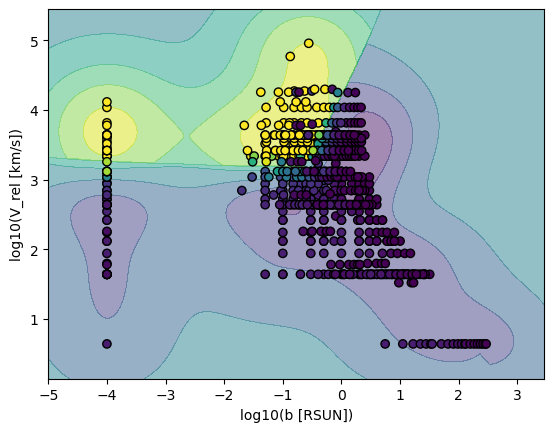

In [46]:
#--- Visualize the decision boundaries ---#
#color bar here indicates fractional mass loss from 0 (purple) to 1(yellow)
svr_gridsearch_plotter(x_data_encoded, x_data, y_data, svc, svc_scaler, svr, svr_scaler, encoder)